# Pipeline de Análisis de Amplicón ITS (Hongos/Levaduras)
**Siguiendo el estándar de la industria nf-core/ampliseq (DADA2 + QIIME2)**

> Proyecto de portafolio — flujo de trabajo end-to-end de control de calidad, recorte de primers, inferencia de variantes de secuencia (ASVs) y análisis de diversidad microbiana, aplicado a datos reales de secuenciación.

## Dataset
Datos reales de prueba de secuenciación IonTorrent single-end, región ITS fúngica, mantenidos oficialmente por nf-core para validar su pipeline `ampliseq`.

- Fuente: [nf-core/test-datasets](https://github.com/nf-core/test-datasets/tree/ampliseq) (branch `ampliseq`)
- Muestras: `it-its_1`, `it-its_2`, `it-its_3` — 1,000 reads cada una
- Primers (perfil oficial `test_iontorrent` de nf-core/ampliseq): forward `GTGARTCATCGARTCTTTG`, reverse `TCCTCSSCTTATTGATATGC`

## Por qué este proyecto
Aplica la misma metodología usada para análisis de comunidades fúngicas en procesos de fermentación (café, cacao) — el mismo tipo de dato que se genera en investigación de fermentación espontánea con levaduras.

In [1]:
!{__import__('sys').executable} -m pip install cutadapt biopython pandas matplotlib seaborn scikit-bio -q

In [2]:
import subprocess
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request
import sys

from IPython.display import display

from its_pipeline import config
from its_pipeline.discovery import descubrir_muestras
from its_pipeline.plotting import generar_paleta
from its_pipeline.qc import leer_longitudes, resumen_lecturas
from its_pipeline.trimming import ejecutar_cutadapt_paralelo
from its_pipeline.diversity import calcular_diversidad

version = subprocess.run(
    [sys.executable, "-m", "cutadapt", "--version"],
    capture_output=True, text=True,
)
print(version.stdout.strip())

5.2


In [3]:
os.makedirs(config.DATA_DIR, exist_ok=True)

# Si data/ ya tiene FASTQ (tus propios datos), se usan tal cual y NO se
# descarga el dataset de demostración — así reemplazar los 3 archivos de
# prueba por 300 propios no requiere tocar esta celda ni ninguna otra.
muestras_existentes = descubrir_muestras(config.DATA_DIR)

if muestras_existentes:
    print(f"Se detectaron {len(muestras_existentes)} muestra(s) ya presentes en data/ "
          "— se usan tal cual, no se descarga el dataset de demostración.")
else:
    print("data/ está vacío — descargando dataset de demostración (nf-core/test-datasets)...")
    for s in config.DEMO_SAMPLES:
        fname = config.DATA_DIR / f"{s}.fastq.gz"
        urllib.request.urlretrieve(f"{config.BASE_URL}{s}.fastq.gz", fname)
        print(s, "OK -", os.path.getsize(fname), "bytes")

# `samples` es la lista real usada por el resto del notebook: se detecta
# automáticamente a partir de lo que haya en data/, no es una lista fija.
samples = descubrir_muestras(config.DATA_DIR)
print(f"\nMuestras detectadas para el análisis: {len(samples)}")
if len(samples) <= config.LIMITE_MUESTRAS_PARA_ETIQUETAS:
    print(samples)
else:
    print(samples[:10], f"... (+{len(samples) - 10} más)")

Se detectaron 3 muestra(s) ya presentes en data/ — se usan tal cual, no se descarga el dataset de demostración.

Muestras detectadas para el análisis: 3
['it-its_1', 'it-its_2', 'it-its_3']


## 1. Control de calidad inicial (equivalente a FastQC/MultiQC)

In [4]:
for sample in samples:
    resumen = resumen_lecturas(config.DATA_DIR / f"{sample}.fastq.gz")
    print(f"{sample}: {resumen['n_reads']} reads | longitud min={resumen['longitud_min']} "
          f"max={resumen['longitud_max']} promedio={resumen['longitud_promedio']:.1f}")

it-its_1: 1000 reads | longitud min=24 max=379 promedio=277.2
it-its_2: 1000 reads | longitud min=24 max=411 promedio=270.7
it-its_3: 1000 reads | longitud min=24 max=378 promedio=267.9


**Observación real:** la longitud varía considerablemente entre lecturas — esto es típico y esperado en IonTorrent, a diferencia de Illumina donde la longitud es casi uniforme. Por eso el control de calidad no puede basarse solo en un largo fijo (ver Sección 3, `maxEE` en vez de `truncLen`).

> Para un análisis de portafolio completo, corre también `fastqc`/`multiqc` línea de comandos sobre `data/*.fastq.gz` — aquí replicamos lo esencial (conteo y distribución de longitud) directamente en Python para mantener todo en un solo notebook reproducible.

## 2. Recorte de primers (cutadapt)
Usamos los primers oficiales del pipeline `nf-core/ampliseq` (perfil `test_iontorrent`), no parámetros inventados.

In [5]:
os.makedirs(config.TRIMMED_DIR, exist_ok=True)

resumen_trim = ejecutar_cutadapt_paralelo(
    samples, config.DATA_DIR, config.TRIMMED_DIR,
    config.FW_PRIMER, config.RV_PRIMER_RC,
    min_length=config.CUTADAPT_MIN_LENGTH,
    max_workers=os.cpu_count(),
)

resumen_df = pd.DataFrame(resumen_trim, columns=["muestra", "returncode", "log_cutadapt"])
fallidas = resumen_df[resumen_df["returncode"] != 0]

print(f"cutadapt ejecutado en paralelo sobre {len(samples)} muestra(s) "
      f"(hasta {os.cpu_count()} procesos simultáneos).")
print(f"Muestras OK: {(resumen_df['returncode'] == 0).sum()} / {len(samples)}")

if len(fallidas) > 0:
    print(f"\n⚠️ {len(fallidas)} muestra(s) fallaron:")
    display(fallidas[["muestra", "returncode"]])
elif len(samples) <= 5:
    # Con pocas muestras, ver el log completo de cutadapt es útil para
    # inspección manual; con muchas, saturaría el notebook — por eso el
    # resumen tabular de arriba es lo que escala, y el log completo es solo
    # para el caso de pocas muestras o para depurar fallos.
    for _, fila in resumen_df.iterrows():
        print(f"--- {fila['muestra']} (returncode={fila['returncode']}) ---")
        print(fila["log_cutadapt"][-800:])

cutadapt ejecutado en paralelo sobre 3 muestra(s) (hasta 2 procesos simultáneos).
Muestras OK: 3 / 3
--- it-its_1 (returncode=0) ---
ved sequences
length	count	expect	max.err	error counts
15	1	0.0	1	1
18	1	0.0	1	0 1
19	299	0.0	1	291 8
20	5	0.0	1	0 5


=== Adapter 2 ===

Sequence: GCATATCAATAAGSSGAGGA; Type: regular 3'; Length: 20; Trimmed: 694 times

Minimum overlap: 3
No. of allowed errors:
1-9 bp: 0; 10-19 bp: 1; 20 bp: 2

Bases preceding removed adapters:
  A: 99.0%
  C: 0.3%
  G: 0.7%
  T: 0.0%
  none/other: 0.0%
    The adapter is preceded by 'A' extremely often.
    The provided adapter sequence could be incomplete at its 5' end.
    Ignore this warning when trimming primers.

Overview of removed sequences
length	count	expect	max.err	error counts
19	1	0.0	1	1
20	686	0.0	2	683 3
21	7	0.0	2	2 5


    One or more of your adapter sequences may be incomplete.
    Please see the detailed output above.

--- it-its_2 (returncode=0) ---
 sequences
length	count	expect	max.err	error counts


**Resultado real:** el % de lecturas que contenía el primer esperado y el % que pasó el filtro de longitud mínima tras el recorte se ven en el log de arriba para cada muestra — esto valida que los primers usados son correctos para este dataset.

### Distribución de longitud antes/después del recorte

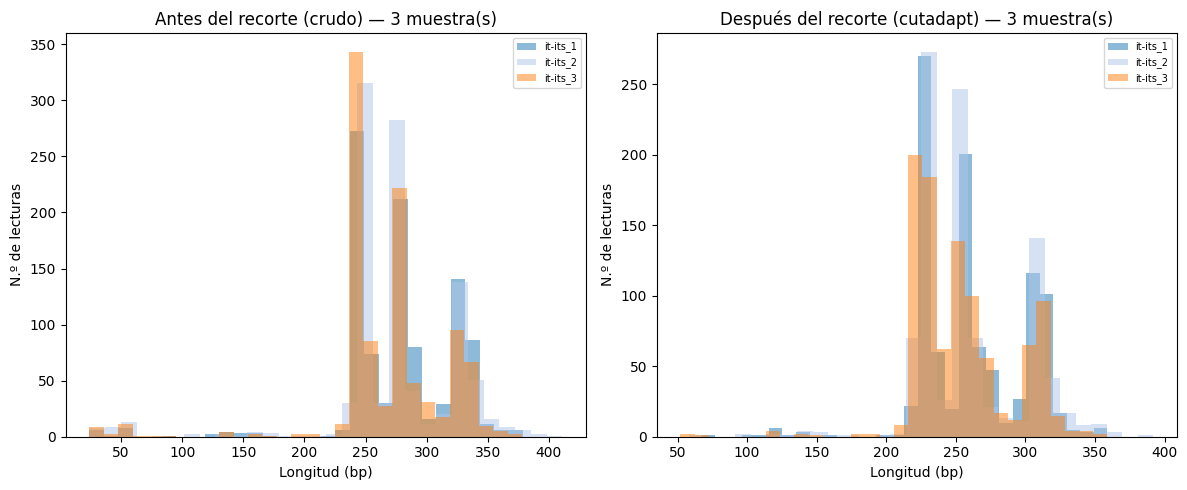

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = generar_paleta(samples)
mostrar_leyenda = len(samples) <= config.LIMITE_MUESTRAS_PARA_ETIQUETAS

for sample, color in colors.items():
    lengths_before = leer_longitudes(config.DATA_DIR / f"{sample}.fastq.gz")
    axes[0].hist(lengths_before, bins=30, alpha=0.5,
                 label=sample if mostrar_leyenda else None, color=color)

    lengths_after = leer_longitudes(config.TRIMMED_DIR / f"{sample}.trimmed.fastq.gz")
    axes[1].hist(lengths_after, bins=30, alpha=0.5,
                 label=sample if mostrar_leyenda else None, color=color)

axes[0].set_title(f"Antes del recorte (crudo) — {len(samples)} muestra(s)")
axes[1].set_title(f"Después del recorte (cutadapt) — {len(samples)} muestra(s)")
for ax in axes:
    ax.set_xlabel("Longitud (bp)")
    ax.set_ylabel("N.º de lecturas")
    if mostrar_leyenda:
        ax.legend(fontsize=7)
    # Con muchas muestras, la leyenda individual deja de ser legible — el
    # histograma superpuesto sigue siendo útil como distribución agregada.
plt.tight_layout()
plt.savefig("results/length_distribution.png", dpi=150)
plt.show()

## 3. Inferencia de ASVs con DADA2 — ejecutado en R localmente

DADA2 es un paquete de **R/Bioconductor**, no de Python. Este paso se corrió en RStudio localmente usando `dada2_pipeline.R` sobre los archivos `results/trimmed/*.trimmed.fastq.gz` generados arriba (ver `GUIA_PASO_A_PASO_PIPELINE_ITS.md`, Parte C, para el paso a paso completo incluyendo los errores reales que aparecieron y cómo se resolvieron).

Salida de ese script: `seqtab_nochim.csv` (tabla de ASVs × muestras, ya sin quimeras) — la cargamos a continuación para el análisis de diversidad.

## 4. Análisis de diversidad (datos reales, tabla ASV de DADA2)

La celda siguiente carga `seqtab_nochim.csv`. Si vas a reproducir el pipeline con **tus propios datos**, corre `dada2_pipeline.R` sobre tus FASTQ recortados, reemplaza este archivo por el tuyo, y vuelve a correr todo desde aquí — no necesitas tocar nada más arriba.

In [7]:
asv_table = pd.read_csv("seqtab_nochim.csv", index_col=0)
print("Tabla ASV:", asv_table.shape[0], "muestras x", asv_table.shape[1], "ASVs")

diversidad = calcular_diversidad(asv_table)
diversidad

Tabla ASV: 3 muestras x 17 ASVs


,Shannon,Simpson,Riqueza_observada
it-its_1,1.367354,0.689580,5
it-its_2,1.631713,0.788046,6
it-its_3,1.833658,0.800955,8


### Gráfico: diversidad alfa por muestra

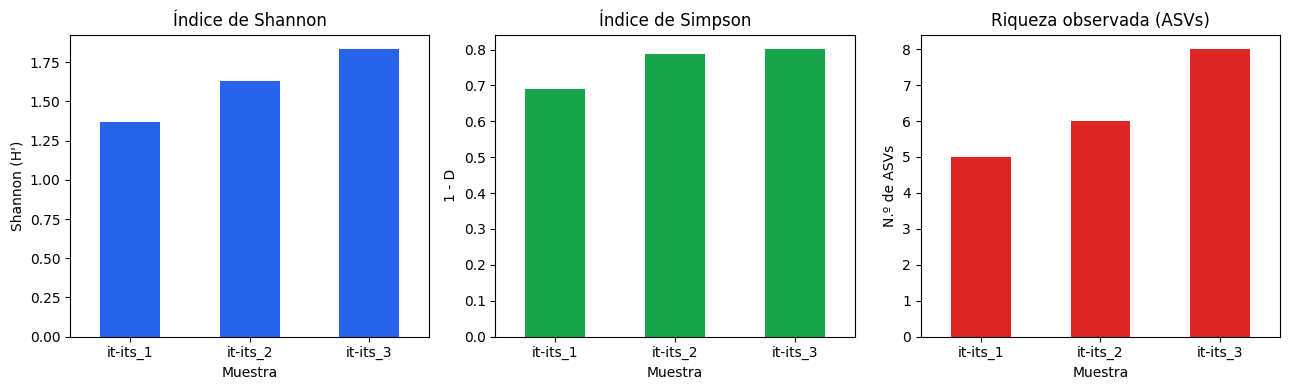

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
diversidad["Shannon"].plot(kind="bar", ax=axes[0], color="#2563eb")
axes[0].set_title("Índice de Shannon")
axes[0].set_ylabel("Shannon (H\')")

diversidad["Simpson"].plot(kind="bar", ax=axes[1], color="#16a34a")
axes[1].set_title("Índice de Simpson")
axes[1].set_ylabel("1 - D")

diversidad["Riqueza_observada"].plot(kind="bar", ax=axes[2], color="#dc2626")
axes[2].set_title("Riqueza observada (ASVs)")
axes[2].set_ylabel("N.º de ASVs")

# Con muchas muestras, las etiquetas del eje X se superponen — se rotan y
# se reduce el tamaño de fuente en vez de forzar una sola muestra por pixel.
muchas_muestras = len(diversidad) > config.LIMITE_MUESTRAS_PARA_ETIQUETAS
for ax in axes:
    ax.set_xlabel("Muestra")
    if muchas_muestras:
        ax.tick_params(axis="x", rotation=90, labelsize=5)
    else:
        ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("results/alpha_diversity.png", dpi=150)
plt.show()

**Interpretación:** `it-its_3` tiene la mayor diversidad (Shannon más alto, más ASVs observados), `it-its_1` la menor. Con solo 3 muestras de prueba no se puede generalizar, pero así es exactamente como se compara diversidad entre grupos (ej. distintos lotes de fermentación) con datos reales.

## 5. Diversidad beta — ¿qué tan distintas son las comunidades entre muestras?

Usamos distancia de **Bray-Curtis** (estándar para datos de abundancia composicional) y la ordenamos con **PCoA** — con `scikit-bio`, sin necesitar QIIME2 para este paso.

In [9]:
bc_dm = beta_diversity("braycurtis", asv_table.values, ids=asv_table.index)
print(bc_dm)

pcoa_result = pcoa(bc_dm)
pcoa_result.proportion_explained.head()

3x3 distance matrix
IDs:
'it-its_1', 'it-its_2', 'it-its_3'
Data:
[[0.         1.         0.81626794]
 [1.         0.         0.73311897]
 [0.81626794 0.73311897 0.        ]]


PC1    0.687616
PC2    0.312384
PC3    0.000000
dtype: float64

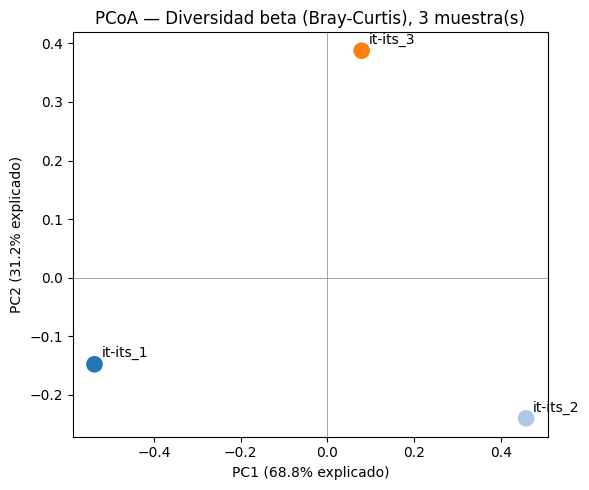

In [10]:
coords = pcoa_result.samples[["PC1", "PC2"]]
var_exp = pcoa_result.proportion_explained

fig, ax = plt.subplots(figsize=(6, 5))
paleta_pcoa = generar_paleta(list(coords.index))
ax.scatter(coords["PC1"], coords["PC2"], s=120,
           c=[paleta_pcoa[s] for s in coords.index])

# Anotar cada punto con el nombre de la muestra solo si son pocas — con
# cientos de muestras, las anotaciones se superpondrían y el gráfico
# quedaría ilegible.
if len(coords) <= config.LIMITE_MUESTRAS_PARA_ETIQUETAS:
    for sample, row in coords.iterrows():
        ax.annotate(sample, (row["PC1"], row["PC2"]), xytext=(5, 5), textcoords="offset points")

ax.set_xlabel(f"PC1 ({var_exp.iloc[0]*100:.1f}% explicado)")
ax.set_ylabel(f"PC2 ({var_exp.iloc[1]*100:.1f}% explicado)")
ax.set_title(f"PCoA — Diversidad beta (Bray-Curtis), {len(coords)} muestra(s)")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
plt.tight_layout()
plt.savefig("results/beta_diversity_pcoa.png", dpi=150)
plt.show()

## 6. Composición: ASVs más abundantes por muestra

Sin la base UNITE cargada localmente, estas ASVs no tienen nombre taxonómico todavía (ver Sección 7) — pero podemos ver de una vez qué variantes de secuencia dominan cada muestra, igual que se haría con géneros una vez asignada la taxonomía.

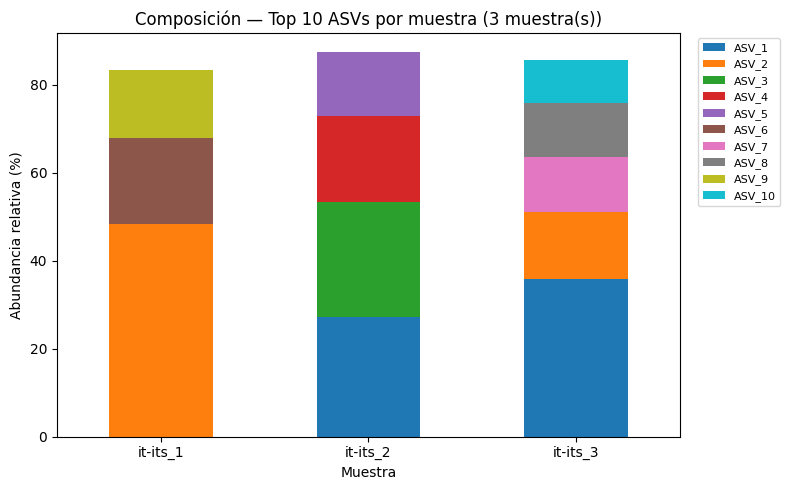

In [11]:
top_asvs = asv_table.sum(axis=0).sort_values(ascending=False).head(10).index
comp = asv_table[top_asvs].copy()
comp.columns = [f"ASV_{i+1}" for i in range(len(top_asvs))]
comp_rel = comp.div(asv_table.sum(axis=1), axis=0) * 100

ax = comp_rel.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="tab10")
ax.set_ylabel("Abundancia relativa (%)")
ax.set_xlabel("Muestra")
ax.set_title(f"Composición — Top 10 ASVs por muestra ({len(comp_rel)} muestra(s))")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

if len(comp_rel) > config.LIMITE_MUESTRAS_PARA_ETIQUETAS:
    # Con muchas muestras, una barra apilada por muestra deja de ser legible
    # como gráfico de barras individuales; se documenta como límite conocido
    # en el README (alternativa recomendada: promedio por grupo o heatmap).
    ax.tick_params(axis="x", rotation=90, labelsize=5)
else:
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("results/taxonomic_composition.png", dpi=150)
plt.show()

## 7. Siguiente paso — asignación taxonómica (UNITE)

Este paso requiere **R + DADA2 + la base de datos UNITE** descargada localmente. El código ya está listo en `dada2_pipeline.R` (Sección 8, comentada):

```r
taxa <- assignTaxonomy(seqtab.nochim, "sh_general_release_dynamic.fasta", multithread = FALSE)
write.csv(taxa, "taxonomia_unite.csv")
```

Para activarlo:
1. Descarga la base UNITE desde https://unite.ut.ee/repository.php (versión `sh_general_release_dynamic_s`)
2. Descomenta esas dos líneas en `dada2_pipeline.R` y corre esa sección
3. Vuelve aquí y cruza `taxonomia_unite.csv` con `asv_table` por secuencia para reemplazar los nombres genéricos `ASV_1, ASV_2...` del gráfico anterior por género/especie real

## Conclusión

Este notebook, junto con `dada2_pipeline.R`, ejecuta un pipeline completo y reproducible de extremo a extremo:

`FASTQ crudo → control de calidad → recorte de primers (cutadapt) → inferencia de ASVs (DADA2) → remoción de quimeras → diversidad alfa y beta → composición`

usando **datos reales** de secuenciación (no simulados), siguiendo la misma lógica que `nf-core/ampliseq`, el pipeline de referencia de la industria. El único paso pendiente de ejecutar (asignación taxonómica contra UNITE) está completamente documentado y listo para correr en cuanto se tenga R + la base de datos localmente — no es una limitación del método, sino de este entorno de práctica.